In [1]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import gudhi


import iblofunmatch.inter as ibfm

from datetime import datetime

_tol = 1e-10

output_dir = "output" # Name of directory to communicate with C++ program
data_dir = os.path.join("datasets")
plots_dir = os.path.join("plots")
os.makedirs(output_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

EXECUTABLE_PATH: /home/atorras/Documents/IBloFunMatch/build/IBloFunMatch


# Table comparing edge collapse iterations and number of point samples 

The following function reads the massif.out files and obtains the maximum memory used in MB at some point during runtime.

In [2]:
def get_peak_memory(filepath):
    """Extracts the maximum total memory (heap + extra) from a massif file.
    Return it in Mb"""
    peak = 0
    with open(filepath, 'r') as f:
        for line in f:
            # We look for 'mem_heap_B' and 'mem_heap_extra_B' 
            # to get a more accurate 'Total' than just heap.
            if line.startswith('mem_heap_B='):
                heap = int(line.split('=')[1].strip())
            elif line.startswith('mem_heap_extra_B='):
                extra = int(line.split('=')[1].strip())
                # Snapshots in massif files usually list heap then extra
                total = heap + extra
                if total > peak:
                    peak = total
    return (peak / 1000000) # Memory in MB

Next, we compute the memory and runtimes, we save on disk since it is a long computation (about 3 hours)

In [3]:
import shutil
from tqdm import tqdm 

runtime_dir = os.path.join(output_dir, "runtime_stats")
if os.path.isdir(runtime_dir):
    shutil.rmtree(runtime_dir)
os.makedirs(runtime_dir)
    
RandGen = np.random.default_rng(5)
num_collapse_iterations = 2
num_points_list = list(range(100,200, 20))
num_iterations_points = 5
for k in range(num_collapse_iterations+1):
    print(f"Collapsing {k} times")
    for i, num_points in tqdm(enumerate(num_points_list), total=len(num_points_list)):
        run_times = []
        run_memory = []
        for j in range(num_iterations_points):
            Z = ibfm.sampled_circle(1.2,1.8,num_points, RandGen)
            indices_subset = list(range(int(num_points*0.5)))
            before = datetime.now()
            matching_data = ibfm.get_IBloFunMatch_subset(None, Z, indices_subset, output_dir, num_it=k, max_rad=-1, points=True, check_memory=True)
            after = datetime.now()
            # append runtimes and memory
            run_times.append((after-before).total_seconds())
            # Memory given in Mb
            run_memory.append(get_peak_memory("massif.out"))
        # end for
        path_prefix = os.path.join(runtime_dir, f"k_{k:01d}_N_{num_points:03d}")
        np.savetxt(path_prefix + "_time.txt", np.array(run_times))
        np.savetxt(path_prefix + "_memory.txt", np.array(run_memory))
    # end for
# end for

Collapsing 0 times


100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [3:29:28<00:00, 2513.61s/it]


Collapsing 1 times


100%|█████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:30<00:00, 18.06s/it]


Collapsing 2 times


100%|█████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:19<00:00, 15.86s/it]


In [4]:
# Memory and times arrays
memory_array = np.zeros((num_collapse_iterations+1, len(num_points_list), num_iterations_points))
times_array = np.zeros((num_collapse_iterations+1, len(num_points_list), num_iterations_points))
# Read memory and times arrays saved on disk
for k in range(num_collapse_iterations+1):
    for i, num_points in enumerate(num_points_list):
        path_prefix = os.path.join(runtime_dir, f"k_{k:01d}_N_{num_points:03d}")
        run_times = np.loadtxt(path_prefix + "_time.txt")
        run_memory = np.loadtxt(path_prefix + "_memory.txt")
        times_array[k,i,:]=run_times
        memory_array[k,i,:]=run_memory
    # end for
# end for

Compute means and save results in case we need to reuse them later.

In [10]:
means_memory = memory_array.mean(axis=2)
means_times = times_array.mean(axis=2)
np.savetxt(runtime_dir + "mean_peak_memory.txt", means_memory)
np.savetxt(runtime_dir + "mean_runtime.txt", means_times)

Here we plot the average memory usage in log MB in function of number of collapse iterations and size of point samples.

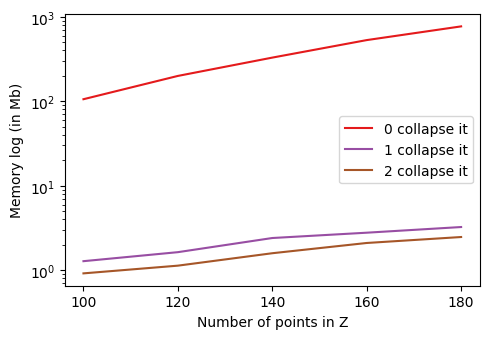

In [11]:

fig, ax = plt.subplots(figsize=(5,3.5))
colormap = mpl.colormaps["Set1"]
for i in range(num_collapse_iterations+1):
    ax.semilogy(list(range(means_memory.shape[1])), means_memory[i], color=colormap(i/(num_collapse_iterations+1)), label=f"{i} collapse it")

ax.legend()
ax.set(
    xlabel = "Number of points in Z",
    ylabel="Memory log (in Mb)", 
    xticks = list(range(len(num_points_list))), 
    xticklabels=num_points_list
)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "memory_comparison.png"))

In [12]:
means_memory

array([[105.8798272, 199.7241632, 329.0398992, 530.2845296, 770.6052432],
       [  1.281832 ,   1.6387504,   2.4095264,   2.7854656,   3.2508576],
       [  0.9193696,   1.134632 ,   1.5918432,   2.1048096,   2.4761392]])

Notice that using the massif tool from Valgrind greatly increases the runtime by comparison to the runtimes obtained from the other analysis in the notebook "Computation-analysis-JSC"

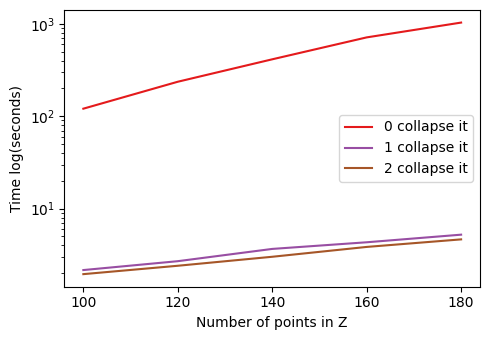

In [13]:

fig, ax = plt.subplots(figsize=(5,3.5))
colormap = mpl.colormaps["Set1"]
for i in range(num_collapse_iterations+1):
    ax.semilogy(list(range(means_times.shape[1])), means_times[i], color=colormap(i/(num_collapse_iterations+1)), label=f"{i} collapse it")

ax.legend()
ax.set(
    xlabel = "Number of points in Z",
    ylabel="Time log(seconds)", 
    xticks = list(range(len(num_points_list))), 
    xticklabels=num_points_list
)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "time_comparison_massif.png"))